# 03 Indexing and Selection

Structural indexing vs parametric selection/evaluation. The central distinction is: `sample=3` is an integer position; `time_s=0.3` is a coordinate-domain query.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

from tal import AnalysisObject
from tal.core import ParamEvalOptions, ParamSelectOptions

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: nonuniform time grids

Nonuniform time makes index-based and param-based operations visibly different.


In [2]:
ds = xr.Dataset(
    data_vars={
        'value': (
            ('trial', 'sample'),
            np.array(
                [
                    [0.0, 0.5, 1.0, 0.2, -0.1],
                    [1.0, 0.8, 0.3, -0.2, -0.4],
                ],
                dtype=float,
            ),
        )
    },
    coords={
        'trial': ['A', 'B'],
        'sample': np.arange(5),
        'time_s': (
            ('trial', 'sample'),
            np.array(
                [[0.0, 0.25, 0.5, 0.75, 1.0], [0.0, 0.2, 0.4, 0.6, 0.8]],
                dtype=float,
            ),
        ),
        'group_size': ('trial', np.array([5, 5], dtype=np.int64)),
    },
)

ao = AnalysisObject.from_data(
    ds,
    sequence_dim='sample',
    batch_dims=('trial',),
    core_dims=(),
    param_coord='time_s',
    sequence_size_coord='group_size',
    validate=True,
)


## Structural indexing with `.isel`, `.sel`, and `.where`

These are xarray-style operations. They operate on dimensions, labels, and masks without inventing new samples.


In [3]:
selection_results = [
    ("isel sample slice", ao.isel({'sample': slice(1, 3)})),
    ("sel trial label", ao.sel({'trial': 'A'})),
    ("where value > 0.2", ao.where(ao.unsafe_data['value'] > 0.2)),
]

for label, result in selection_results:
    display_result(label, result, data=False)


#### isel sample slice

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'sample': 2}"
2,data_vars,[value]
3,coords,"[trial, sample, time_s, group_size]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time_s
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,value,"(trial, sample)","(2, 2)",float64
1,coord,trial,"(trial,)","(2,)",<U1
2,coord,sample,"(sample,)","(2,)",int64
3,coord,time_s,"(trial, sample)","(2, 2)",float64
4,coord,group_size,"(trial,)","(2,)",int64


#### sel trial label

,field,value
0,type,AnalysisObject
1,dims,{'sample': 5}
2,data_vars,[value]
3,coords,"[trial, sample, time_s, group_size]"
4,batch_dims,()
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time_s
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,value,"(sample,)","(5,)",float64
1,coord,trial,(),(),<U1
2,coord,sample,"(sample,)","(5,)",int64
3,coord,time_s,"(sample,)","(5,)",float64
4,coord,group_size,(),(),int64


#### where value > 0.2

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'sample': 5}"
2,data_vars,[value]
3,coords,"[trial, sample, time_s, group_size]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,value,"(trial, sample)","(2, 5)",float64
1,coord,trial,"(trial,)","(2,)",<U1
2,coord,sample,"(sample,)","(5,)",int64
3,coord,time_s,"(trial, sample)","(2, 5)",float64
4,coord,group_size,"(trial,)","(2,)",int64


What to notice

`isel` slices by integer position, `sel` uses existing labels, and `where` preserves layout while masking values.


## Param selection vs param evaluation

`param.sel` chooses existing samples by policy. `param.at` evaluates values at requested parameter coordinates.


In [4]:
queries = np.array([0.1, 0.55, 0.9], dtype=float)
picked = ao.param.sel(
    queries,
    on='time_s',
    opts=ParamSelectOptions(method='nearest', layout='packed'),
)
evaluated = ao.param.at(
    queries,
    on='time_s',
    opts=ParamEvalOptions(method='linear'),
)

display_result('param.sel nearest samples', picked, data=False)
display_result('param.at linear interpolation', evaluated, data=False)


#### param.sel nearest samples

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'sample': 3}"
2,data_vars,[value]
3,coords,"[trial, time_s, group_size, sample_index, vali..."
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,value,"(trial, sample)","(2, 3)",float64
1,coord,trial,"(trial,)","(2,)",<U1
2,coord,time_s,"(sample,)","(3,)",float64
3,coord,group_size,"(trial,)","(2,)",int64
4,coord,sample_index,"(trial, sample)","(2, 3)",int64
5,coord,valid,"(trial, sample)","(2, 3)",bool
6,coord,sample,"(sample,)","(3,)",int64


#### param.at linear interpolation

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'sample': 3}"
2,data_vars,[value]
3,coords,"[trial, group_size, valid, sample, time_s]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,value,"(trial, sample)","(2, 3)",float64
1,coord,trial,"(trial,)","(2,)",<U1
2,coord,group_size,"(trial,)","(2,)",int64
3,coord,valid,"(trial, sample)","(2, 3)",bool
4,coord,sample,"(sample,)","(3,)",int64
5,coord,time_s,"(sample,)","(3,)",float64


What to notice

`picked` contains existing sample values; `evaluated` contains values computed on the query grid.


## Visual confirmation

A plot is useful here because it confirms whether an operation selected existing samples or interpolated between them.


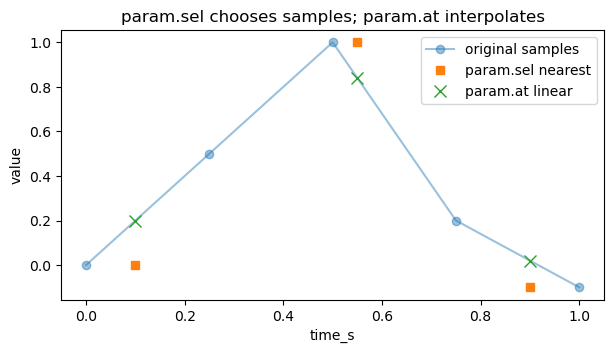

In [7]:
source_ds = ao.unsafe_data
nearest_ds = picked.unsafe_data
evaluated_ds = evaluated.unsafe_data

source_time = source_ds['time_s'].sel(trial='A') if 'trial' in source_ds['time_s'].dims else source_ds['time_s']
source = source_ds['value'].sel(trial='A')
nearest = nearest_ds['value'].sel(trial='A')
evaluated_values = evaluated_ds['value'].sel(trial='A')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(source_time, source, '-o', alpha=0.45, label='original samples')
ax.plot(queries, nearest, 's', label='param.sel nearest')
ax.plot(queries, evaluated_values, 'x', markersize=9, label='param.at linear')
ax.set(
    title='param.sel chooses samples; param.at interpolates',
    xlabel='time_s',
    ylabel='value',
)
ax.legend(loc='best')


## Failure boundary: nonmonotonic parameter coordinate

Interpolation/search requires an ordered param coordinate within each trajectory. TAL fails clearly when that assumption is violated.


In [6]:
bad_ds = ds.copy(deep=True)
bad_ds = bad_ds.assign_coords(
    time_s=(
        ('trial', 'sample'),
        np.array(
            [[0.0, 0.25, 0.5, 0.75, 1.0], [0.0, 0.3, 0.2, 0.6, 0.8]],
            dtype=float,
        ),
    )
)
bad_ao = AnalysisObject.from_data(
    bad_ds,
    sequence_dim='sample',
    batch_dims=('trial',),
    core_dims=(),
    param_coord='time_s',
    sequence_size_coord='group_size',
    validate=True,
)

try:
    bad_ao.param.at([0.1, 0.5], on='time_s')
except ValueError as exc:
    print('fail-closed:', str(exc).split(':')[0])


fail-closed: build_param_map


## When to use each method

| Question | Use |
|---|---|
| integer positions | `.isel(...)` |
| existing labels | `.sel(...)` |
| shape-preserving mask | `.where(...)` |
| nearest existing param sample | `.param.sel(...)` |
| interpolated/evaluated param values | `.param.at(...)` |

**Exercise:** change the query values and compare `ParamSelectOptions(method="nearest")` with `ParamEvalOptions(method="linear")`.
